## 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 2.Load the Dataset

In [2]:
df = pd.read_csv('dataset/fifa_player_performance_market_value.csv')
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


## 3.Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

In [4]:
df.describe()

,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,27.952500,76.866786,81.563929,27.135714,19.261786,12.015000,2250.101429,90.565500,2.527857
std,808.434702,6.750192,9.921113,9.755799,15.979627,11.567858,7.188459,1295.461829,52.078881,1.699445
min,1.000000,17.000000,60.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.000000
25%,700.750000,22.000000,68.000000,73.000000,13.750000,9.000000,6.000000,1131.250000,45.355000,1.000000
50%,1400.500000,28.000000,77.000000,82.000000,27.000000,19.000000,12.000000,2251.000000,89.170000,3.000000
75%,2100.250000,34.000000,85.000000,90.000000,41.000000,30.000000,18.000000,3366.250000,136.682500,4.000000
max,2800.000000,39.000000,94.000000,98.000000,54.000000,39.000000,24.000000,4497.000000,179.960000,5.000000


In [5]:
df.describe(include='object')

,player_name,nationality,club,position,injury_prone,transfer_risk_level
count,2800,2800,2800,2800,2800,2800
unique,2800,8,7,9,2,3
top,Player_2784,Brazil,Juventus,ST,No,Low
freq,1,380,439,329,2125,1250


## 4.Missing Values Analysis

In [6]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage' : (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=False)
print('Columns with Missing Values:')
missing

Columns with Missing Values:


,Missing Count,Missing Percentage


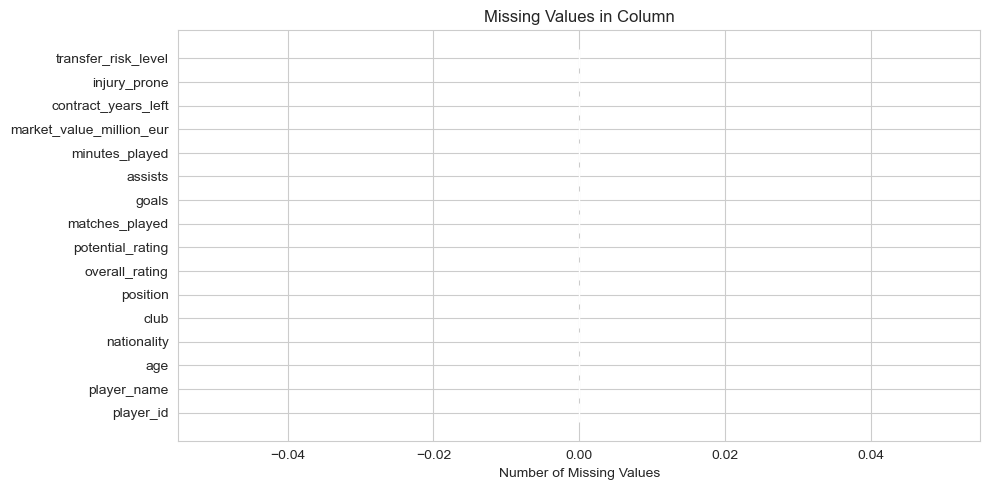

In [7]:
fig,ax = plt.subplots(figsize=(10,5))
colors = ["#e74c3c" if df[col].isnull().any() else "#2ecc71" for col in df.columns]

ax.barh(df.columns,df.isnull().sum(),color=colors)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Values in Column')

for i,value in enumerate(df.isnull().sum()):
    if value > 0:
        ax.text(value + 5,i,str(value),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 5.Target Variable Analysis

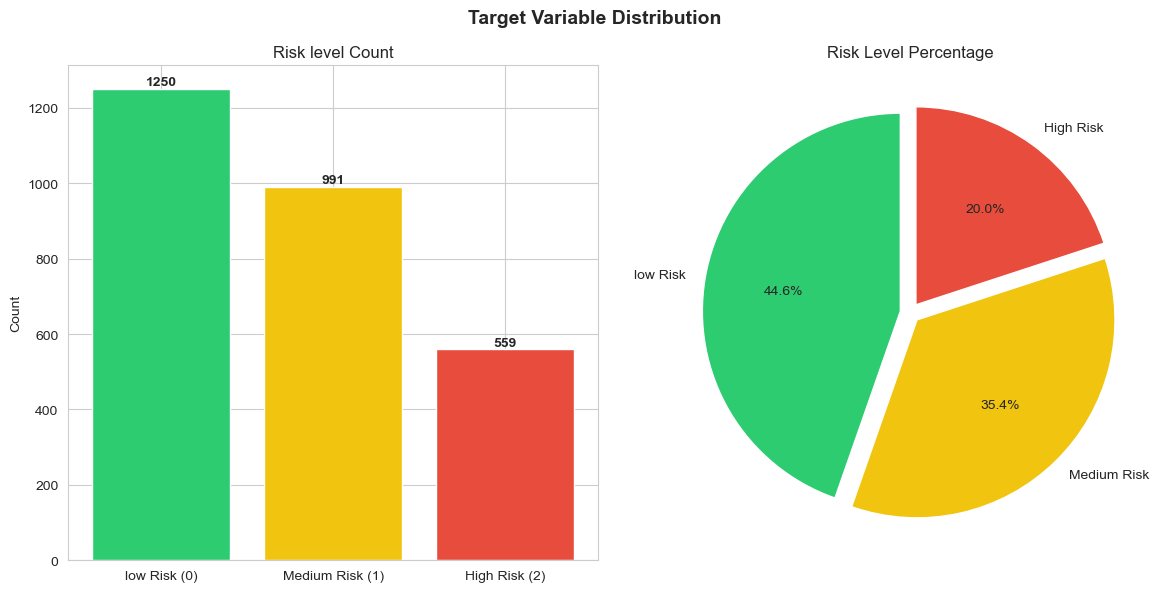

Risk Low Transfer Rate 44.64%
Risk Medium Transfer Rate 35.39%
Risk Hihg Transfer Rate 19.96%


In [8]:
fig,axes = plt.subplots(1,2,figsize=(12,6))
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

# Count Plot
transvelRisklevel = df['transfer_risk_level'].value_counts()
axes[0].bar(['low Risk (0)','Medium Risk (1)','High Risk (2)'],transvelRisklevel.values,color=colors)
axes[0].set_title('Risk level Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(transvelRisklevel.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie Cart
axes[1].pie(transvelRisklevel.values,labels=['low Risk','Medium Risk','High Risk'],
            autopct="%1.1f%%", colors=colors,startangle=90, explode=(0.05, 0.05,0.05))
axes[1].set_title('Risk Level Percentage')

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

rate_Risklow = (len(df[df['transfer_risk_level'] == 'Low']) / len(df))
rate_Riskmedium = (len(df[df['transfer_risk_level'] == 'Medium']) / len(df))
rate_Riskhigh = (len(df[df['transfer_risk_level'] == 'High']) / len(df))

print(f'Risk Low Transfer Rate {rate_Risklow:.2%}')
print(f'Risk Medium Transfer Rate {rate_Riskmedium:.2%}')
print(f'Risk Hihg Transfer Rate {rate_Riskhigh:.2%}')

## 6.Univariat Analysis --- Numerical Features

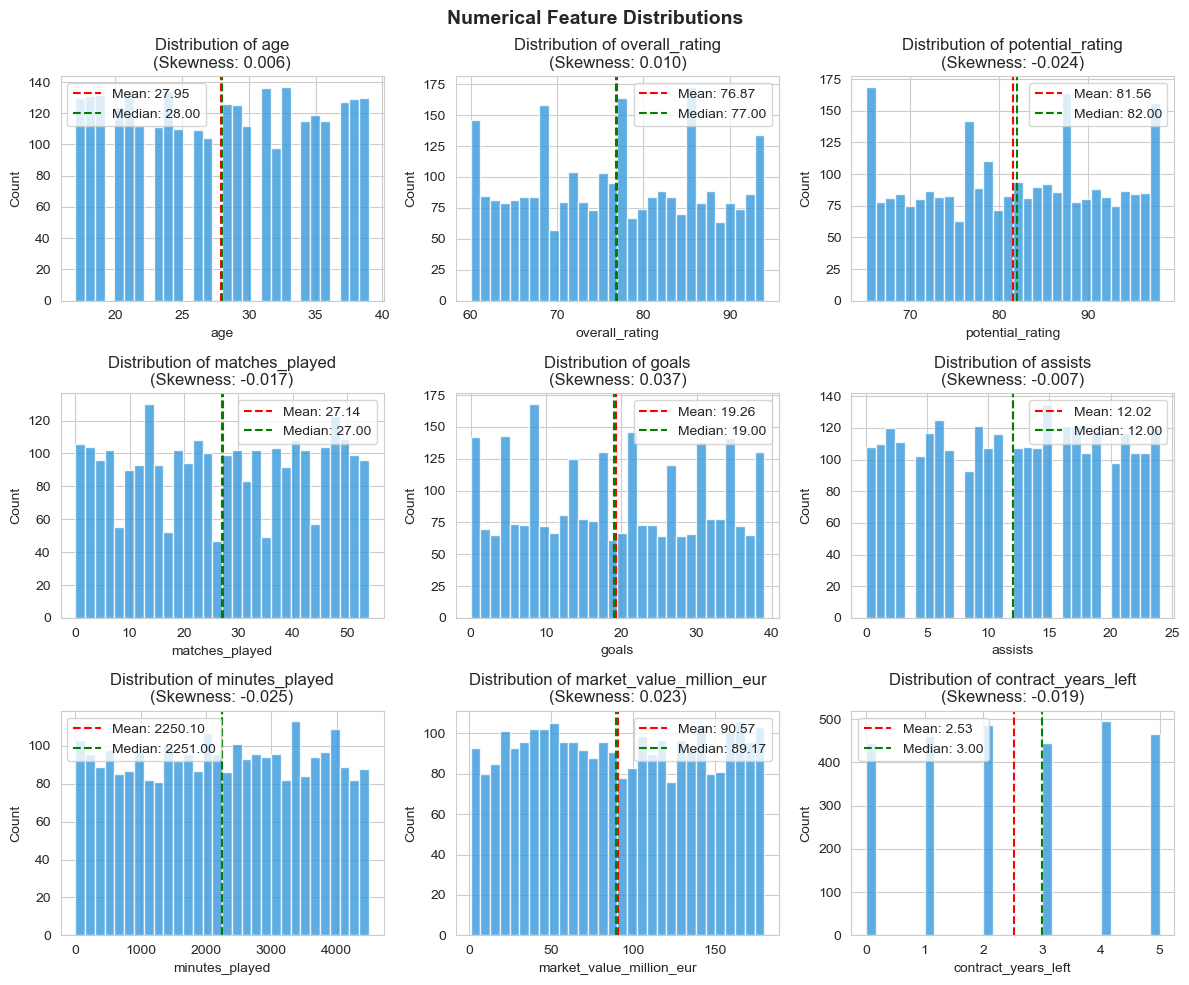

In [9]:
df_target = df.drop(columns='player_id').copy()
feature_numerik = df_target.select_dtypes(include=np.number).columns

fig,axes = plt.subplots(3,3,figsize=(12,10))
axes = axes.flatten()

for i,col in enumerate(feature_numerik):
    feat_skew = df_target[col].skew()
    axes[i].hist(df_target[col].dropna(),bins=30,color='#3498db',edgecolor='white',alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}\n(Skewness: {feat_skew:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()
    
plt.suptitle('Numerical Feature Distributions',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


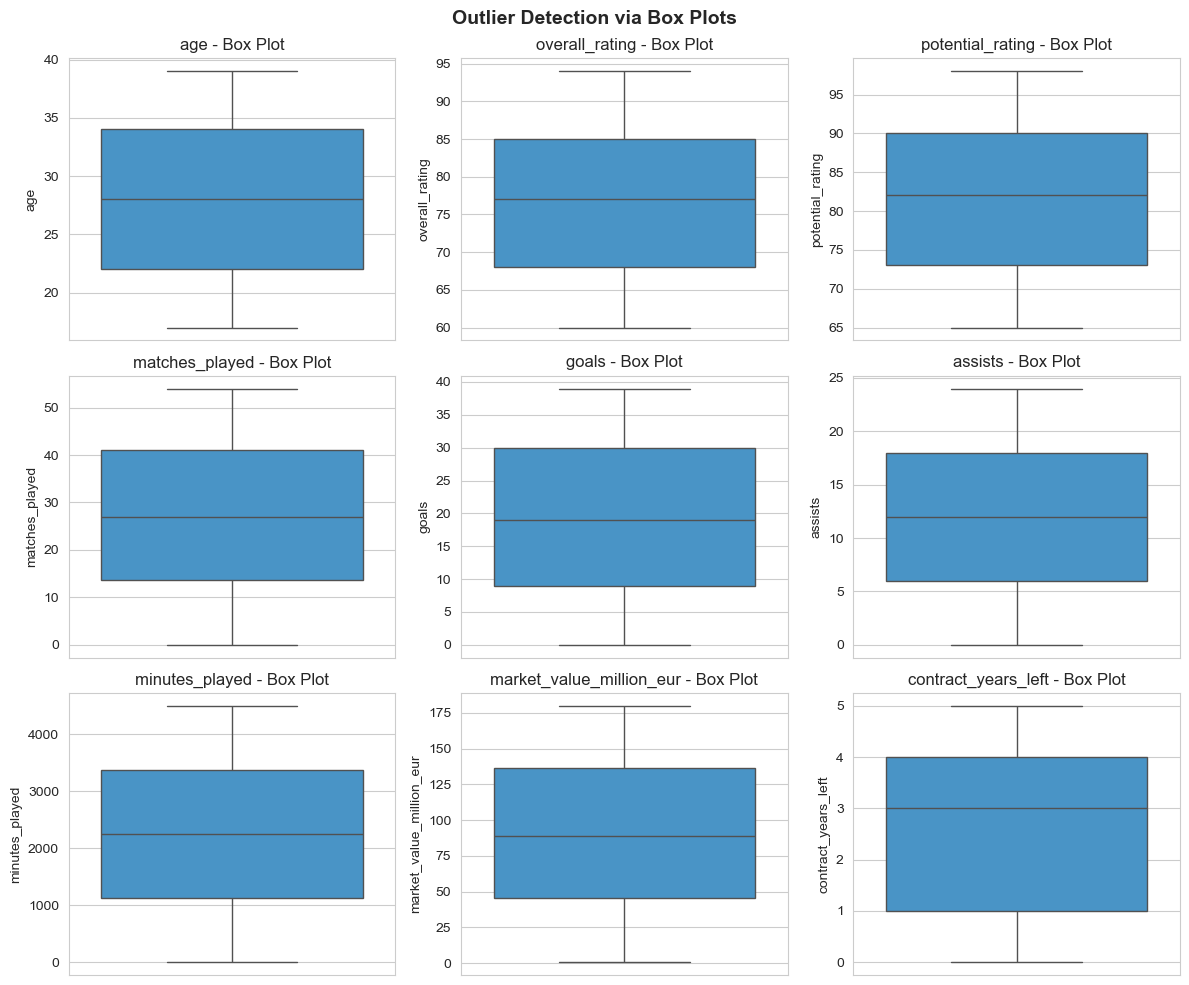

In [10]:
fig,axes = plt.subplots(3,3,figsize=(12,10))
axes = axes.flatten()

for i,col in enumerate(feature_numerik):
    sns.boxplot(y=df_target[col],ax=axes[i],color='#3498db')
    axes[i].set_title(f'{col} - Box Plot')

plt.suptitle('Outlier Detection via Box Plots',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

## 7.Univariate Analysis -- Categorical Features

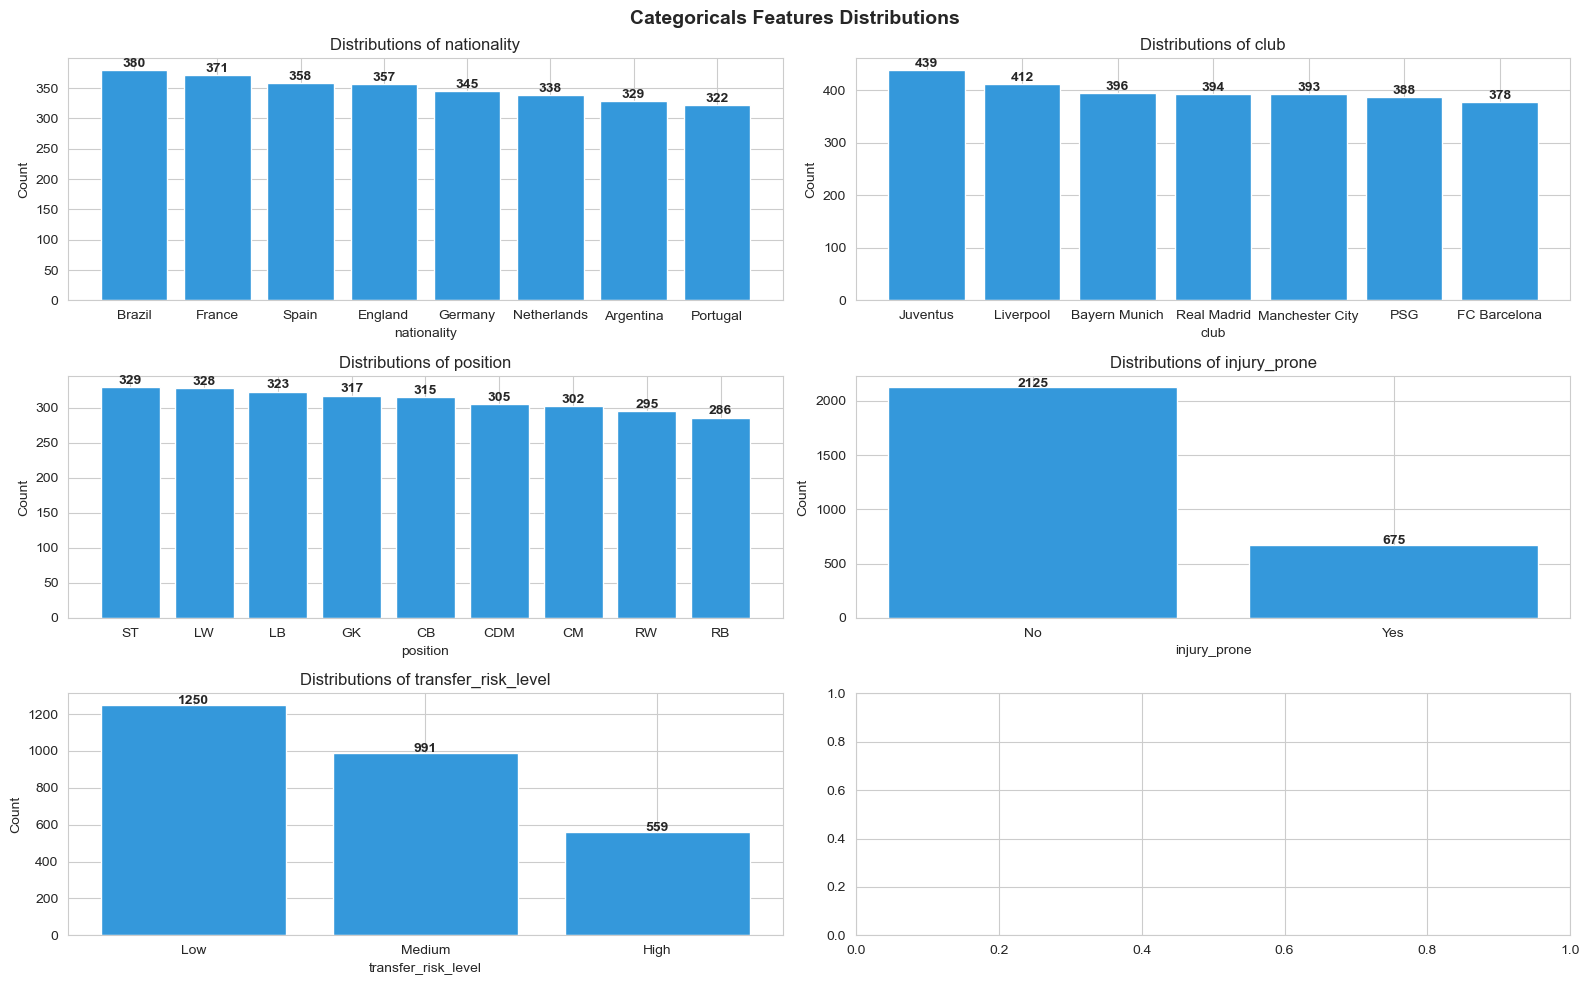

In [15]:
df_target = df.drop(columns='player_name').copy()
feature_categori = df_target.select_dtypes(include='object').columns

fig,axes = plt.subplots(3,2,figsize=(16,10))
axes = axes.flatten()

for i,col in enumerate(feature_categori):
    counts = df_target[col].value_counts()
    axes[i].bar(x=counts.index.astype(str),height=counts.values,color='#3498db',edgecolor='white')
    axes[i].set_title(f'Distributions of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle('Categoricals Features Distributions',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()
